### Cargar Red

In [ ]:
import pypsa
n = #Red

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units


Plot saved as 'monthly_demand_argentina.png'
Data saved as 'monthly_demand_data.csv'


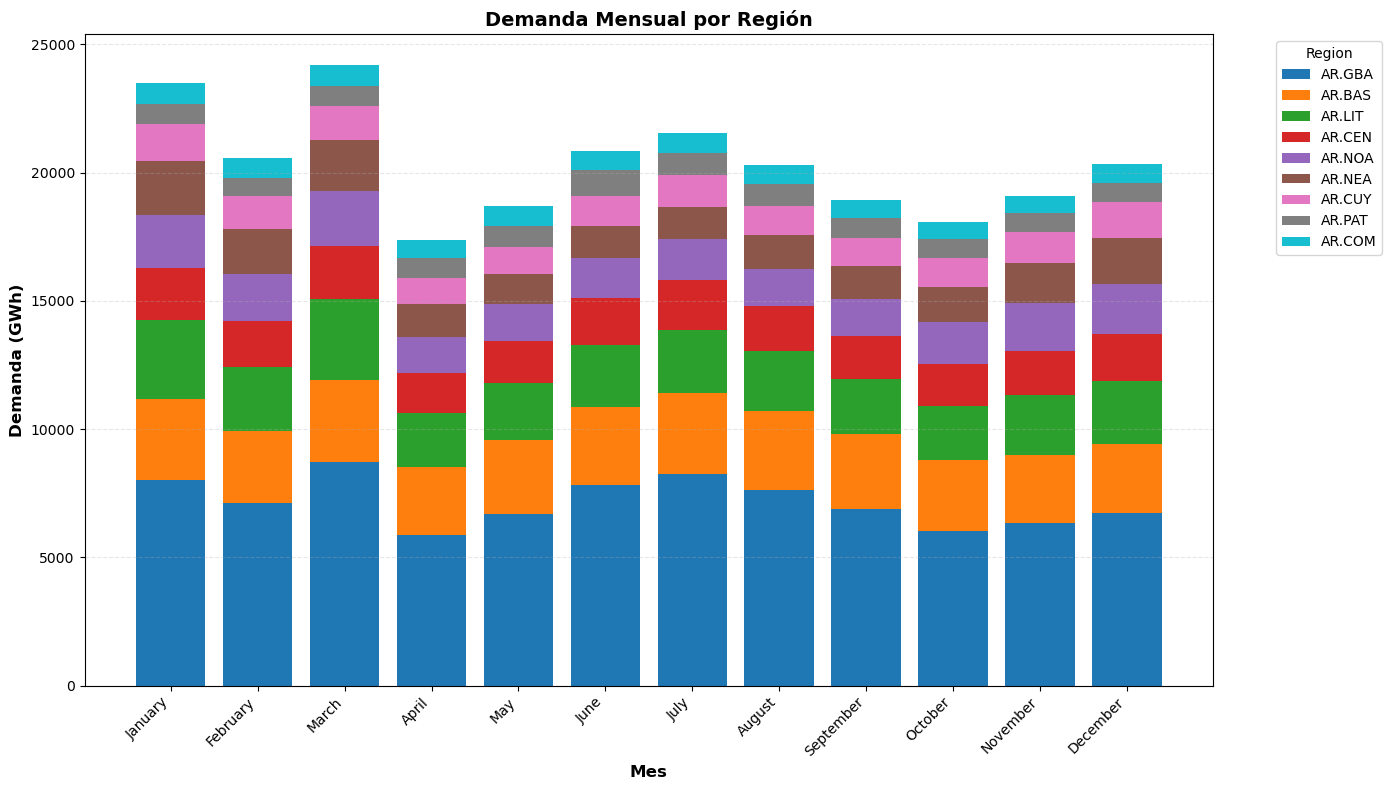


=== Summary Statistics ===

Total annual demand: 243361.26 GWh

Demand by region (GWh/year):
AR.GBA    86046.475254
AR.BAS    35004.016326
AR.LIT    29250.506414
AR.CEN    21568.948628
AR.NOA    20379.509356
AR.NEA    18102.946439
AR.CUY    14547.537481
AR.PAT     9580.039482
AR.COM     8881.283726
dtype: float64

Peak month: March (24178.23 GWh)
Lowest month: April (17353.83 GWh)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract load data (demand) from the network
# Check if we have time series data
if hasattr(n.loads_t, 'p_set') and not n.loads_t.p_set.empty:
    load_data = n.loads_t.p_set  # Power in MW
    
elif hasattr(n.loads_t, 'p') and not n.loads_t.p.empty:
    load_data = n.loads_t.p  # Alternative: actual load
    
else:
    raise ValueError("No time series load data found in network!")

# Get the bus names for each load
load_to_bus = n.loads.bus

# Create a dataframe with demand by bus
demand_by_bus = pd.DataFrame(index=load_data.index)
for load in load_data.columns:
    bus = load_to_bus[load]
    if bus not in demand_by_bus.columns:
        demand_by_bus[bus] = 0
    demand_by_bus[bus] += load_data[load]

# Convert index to datetime if it isn't already
if not isinstance(demand_by_bus.index, pd.DatetimeIndex):
    demand_by_bus.index = pd.to_datetime(demand_by_bus.index)

# Group by month and sum to get monthly demand
# Convert from MW to GWh (MW * hours in the period / 1000)
# Assuming hourly data, we sum MW values and divide by 1000 to get GWh
monthly_demand = demand_by_bus.groupby(demand_by_bus.index.to_period('M')).sum() / 1000

# Check if we have data
if monthly_demand.empty:
    raise ValueError("Monthly demand dataframe is empty! Check your data.")

# Convert period index to month names, keeping year information if multi-year
if len(monthly_demand) > 12:
    # Multi-year data - keep year info
    monthly_demand.index = monthly_demand.index.strftime('%b %Y')
else:
    # Single year - just month names
    monthly_demand.index = monthly_demand.index.strftime('%B')

# Sort columns (regions) by total annual demand (largest to smallest)
# This will make the largest consumer at the bottom of the stack
total_demand_by_region = monthly_demand.sum().sort_values(ascending=False)
monthly_demand = monthly_demand[total_demand_by_region.index]

# Reset index to make month names a regular column for better plotting
monthly_demand_plot = monthly_demand.copy()
month_labels = monthly_demand_plot.index.tolist()

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Generate colors for the 9 regions
colors = plt.cm.tab10(np.linspace(0, 0.9, len(monthly_demand_plot.columns)))

# Create stacked bar chart
x_pos = np.arange(len(monthly_demand_plot))
bottom = np.zeros(len(monthly_demand_plot))

# Plot each region as a bar segment
bars = []
for i, region in enumerate(monthly_demand_plot.columns):
    bar = ax.bar(x_pos, monthly_demand_plot[region], bottom=bottom, 
                 color=colors[i], label=region, width=0.8)
    bars.append(bar)
    bottom += monthly_demand_plot[region].values

# Customize the plot
ax.set_xticks(x_pos)
ax.set_xticklabels(month_labels, rotation=45, ha='right')
ax.set_xlabel('Mes', fontsize=12, fontweight='bold')
ax.set_ylabel('Demanda (GWh)', fontsize=12, fontweight='bold')
ax.set_title('Demanda Mensual por Región', fontsize=14, fontweight='bold')
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('monthly_demand_argentina.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'monthly_demand_argentina.png'")

# Also save the data to CSV for reference
monthly_demand.to_csv('monthly_demand_data.csv')
print("Data saved as 'monthly_demand_data.csv'")

# Display the plot
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"\nTotal annual demand: {monthly_demand.sum().sum():.2f} GWh")
print(f"\nDemand by region (GWh/year):")
print(monthly_demand.sum().sort_values(ascending=False))
print(f"\nPeak month: {monthly_demand.sum(axis=1).idxmax()} ({monthly_demand.sum(axis=1).max():.2f} GWh)")
print(f"Lowest month: {monthly_demand.sum(axis=1).idxmin()} ({monthly_demand.sum(axis=1).min():.2f} GWh)")

### Curva de Carga

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units


Plotting total system load curve
Plot saved as: load_curve_system.png


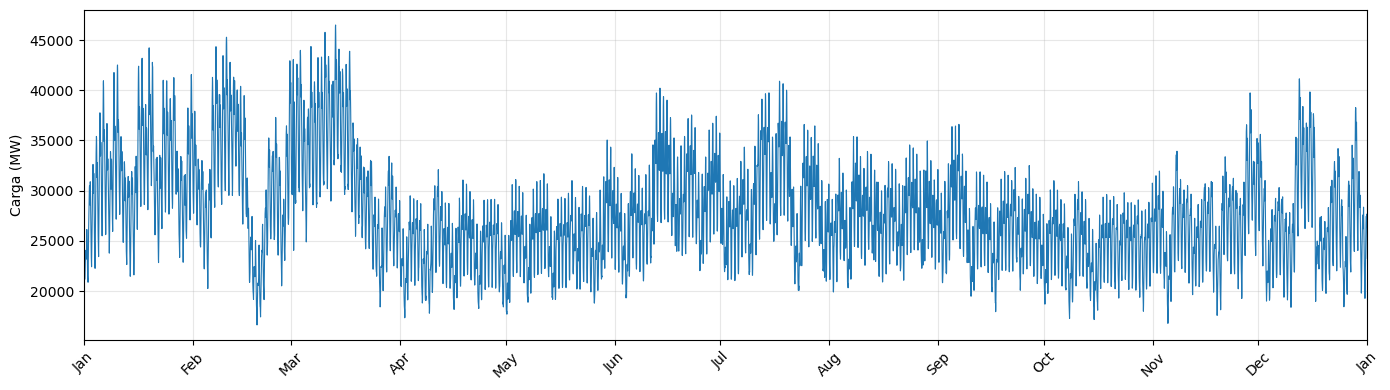


=== Load Statistics for Total System ===
Average load: 27780.97 MW
Peak load: 46496.43 MW (at 2013-03-13 15:00:00)
Minimum load: 16629.68 MW (at 2013-02-19 07:00:00)
Total energy: 243361.26 GWh


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========================================
# USER INPUT: Change this to select a bus
# ========================================
selected_bus = ""  # Change this to any bus name, or "" to plot the total system load
# ========================================

# Get load data
load_data = n.loads_t.p_set

# If a specific bus is selected, filter loads for that bus
# Check for None, empty string, or the string "None"
if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    # Find all loads connected to the selected bus
    loads_in_bus = n.loads[n.loads.bus == selected_bus].index
    
    if len(loads_in_bus) == 0:
        print(f"ERROR: No loads found for bus '{selected_bus}'")
        print(f"\nAvailable buses:")
        print(n.buses.index.tolist())
        raise ValueError(f"Bus '{selected_bus}' not found or has no loads")
    
    # Sum all loads in this bus
    bus_load_MW = load_data[loads_in_bus].sum(axis=1)
    title_suffix = f"Bus: {selected_bus}"
    print(f"Plotting load curve for bus: {selected_bus}")
    print(f"Number of loads in this bus: {len(loads_in_bus)}")
else:
    # Total system load
    bus_load_MW = load_data.sum(axis=1)
    title_suffix = "Total System"
    print("Plotting total system load curve")

# Define time window
start = pd.Timestamp("2013-01-01 00:00:00")
end   = pd.Timestamp("2014-01-01 00:00:00")

# Filter data for the selected time window
selected_load = bus_load_MW.loc[
    (bus_load_MW.index >= start) &
    (bus_load_MW.index <= end)
]

# Create the plot
plt.figure(figsize=(14, 4))
plt.plot(selected_load.index, selected_load.values, linewidth=0.8)
plt.ylabel("Carga (MW)")
plt.xlim(start, end)


# Format x-axis adaptively based on the time window duration
ax = plt.gca()
duration = (end - start).days

if duration <= 1:
    # Less than or equal to 1 day: show hours and minutes
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))  # Every 2 hours
elif duration <= 7:
    # 1 week or less: show day and hour
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:00'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
elif duration <= 31:
    # 1 month or less: show month and day
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Every 2 days
elif duration <= 90:
    # 3 months or less: show month and day
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Every week
else:
    # More than 3 months: show month only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    filename = f"load_curve_{selected_bus}.png"
else:
    filename = "load_curve_system.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Plot saved as: {filename}")

plt.show()

# Print some statistics
print(f"\n=== Load Statistics for {title_suffix} ===")
print(f"Average load: {selected_load.mean():.2f} MW")
print(f"Peak load: {selected_load.max():.2f} MW (at {selected_load.idxmax()})")
print(f"Minimum load: {selected_load.min():.2f} MW (at {selected_load.idxmin()})")
print(f"Total energy: {selected_load.sum()/1000:.2f} GWh")

### Minimo, maximo y medio

Plotting diurnal envelope for total system
Plot saved as: diurnal_envelope_system.png


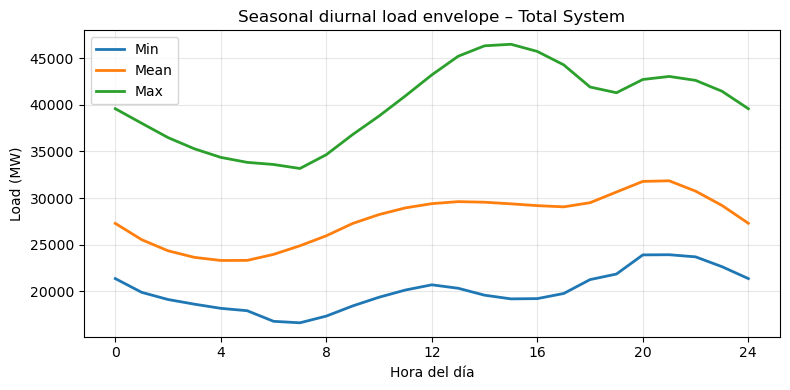


=== Diurnal Load Envelope Statistics for Total System ===
Period: 2013-01-01 to 2014-01-01

Overall statistics:
  Absolute minimum: 16629.68 MW (hour 7)
  Daily average load: 27761.68 MW
  Absolute maximum: 46496.43 MW (hour 15)
  Peak-to-valley ratio: 2.80


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ========================================
# USER INPUT: Change these settings
# ========================================
selected_bus = ""  # Change this to any bus name, or "" to plot the total system load

# Define time window
start = pd.Timestamp("2013-01-01 00:00:00")
end   = pd.Timestamp("2014-01-01 00:00:00")
# ========================================

# Get load data
load_data = n.loads_t.p_set

# If a specific bus is selected, filter loads for that bus
# Check for None, empty string, or the string "None"
if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    # Find all loads connected to the selected bus
    loads_in_bus = n.loads[n.loads.bus == selected_bus].index
    
    if len(loads_in_bus) == 0:
        print(f"ERROR: No loads found for bus '{selected_bus}'")
        print(f"\nAvailable buses:")
        print(n.buses.index.tolist())
        raise ValueError(f"Bus '{selected_bus}' not found or has no loads")
    
    # Sum all loads in this bus
    system_load_MW = load_data[loads_in_bus].sum(axis=1)
    title_suffix = f"Bus: {selected_bus}"
    print(f"Plotting diurnal envelope for bus: {selected_bus}")
    print(f"Number of loads in this bus: {len(loads_in_bus)}")
else:
    # Total system load
    system_load_MW = load_data.sum(axis=1)
    title_suffix = "Total System"
    print("Plotting diurnal envelope for total system")

# Filter data for the selected time window
summer_load = system_load_MW.loc[(system_load_MW.index >= start) & (system_load_MW.index < end)]

# Calculate envelope (min, mean, max) by hour of day
by_hour = summer_load.groupby(summer_load.index.hour)
envelope = pd.DataFrame({
    "min": by_hour.min(),
    "mean": by_hour.mean(),
    "max": by_hour.max(),
}).sort_index()

# Add the "24:00" point using next-day 00:00 values (so the last segment is shown)
next_midnights = system_load_MW.loc[
    (system_load_MW.index >= start + pd.Timedelta(days=1)) &
    (system_load_MW.index <= end) &
    (system_load_MW.index.hour == 0)
]
envelope.loc[24, ["min","mean","max"]] = [next_midnights.min(), next_midnights.mean(), next_midnights.max()]

envelope = envelope.sort_index()

# Create the plot
plt.figure(figsize=(8, 4))
plt.plot(envelope.index, envelope["min"], label="Min", linewidth=2)
plt.plot(envelope.index, envelope["mean"], label="Mean", linewidth=2)
plt.plot(envelope.index, envelope["max"], label="Max", linewidth=2)
plt.xlabel("Hora del día")
plt.ylabel("Load (MW)")
plt.title(f"Seasonal diurnal load envelope – {title_suffix}")
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the plot
if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    filename = f"diurnal_envelope_{selected_bus}.png"
else:
    filename = "diurnal_envelope_system.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Plot saved as: {filename}")

plt.show()

# Print statistics
print(f"\n=== Diurnal Load Envelope Statistics for {title_suffix} ===")
print(f"Period: {start.date()} to {end.date()}")
print(f"\nOverall statistics:")
print(f"  Absolute minimum: {envelope['min'].min():.2f} MW (hour {envelope['min'].idxmin()})")
print(f"  Daily average load: {envelope['mean'].mean():.2f} MW")
print(f"  Absolute maximum: {envelope['max'].max():.2f} MW (hour {envelope['max'].idxmax()})")
print(f"  Peak-to-valley ratio: {envelope['max'].max() / envelope['min'].min():.2f}")

### Carga neta

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, loads, storage_units


Plotting total system net load curve
Renewable carriers found: ['onwind', 'solar']
Number of active renewable generators: 18
Plot saved as: net_load_curve_system.png


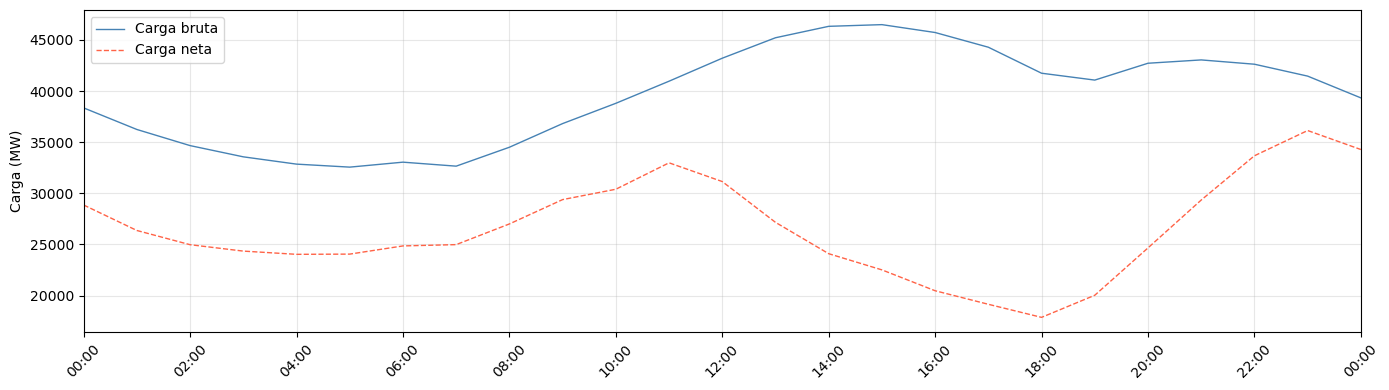


=== Net Load Statistics for Total System ===
Average net load:  26506.61 MW
Peak net load:     36137.55 MW (at 2013-03-13 23:00:00)
Minimum net load:  17861.49 MW (at 2013-03-13 18:00:00)
Total net energy:  662.67 GWh

Average renewable generation: 13024.53 MW
Renewable peak:               25259.99 MW


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========================================
# USER INPUT: Change this to select a bus
# ========================================
selected_bus = ""  # Change this to any bus name, or "" to plot the total system
# ========================================

# --- LOAD ---
load_data = n.loads_t.p_set

if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    loads_in_bus = n.loads[n.loads.bus == selected_bus].index
    if len(loads_in_bus) == 0:
        print(f"ERROR: No loads found for bus '{selected_bus}'")
        print(f"\nAvailable buses:")
        print(n.buses.index.tolist())
        raise ValueError(f"Bus '{selected_bus}' not found or has no loads")
    bus_load_MW = load_data[loads_in_bus].sum(axis=1)
    title_suffix = f"Bus: {selected_bus}"
    print(f"Plotting net load curve for bus: {selected_bus}")
else:
    bus_load_MW = load_data.sum(axis=1)
    title_suffix = "Total System"
    print("Plotting total system net load curve")

# --- RENEWABLE GENERATION ---
# Identify renewable carriers (adjust this list to match your network's carrier names)
renewable_carriers = ["solar", "onwind"]

# Get actual dispatch of generators (p_t for dispatchable, p_max_pu * p_nom_opt for VRE)
# For VRE generators in PyPSA-Earth, actual generation is in generators_t.p
gen_t = n.generators_t.p  # actual dispatch time series

# Filter renewable generators
renewable_gens = n.generators[n.generators.carrier.isin(renewable_carriers)].index
# Keep only those that have a time series (some may be missing if p_nom_opt = 0)
renewable_gens_active = [g for g in renewable_gens if g in gen_t.columns]

if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    # Filter renewables connected to the selected bus
    renewable_gens_active = [
        g for g in renewable_gens_active
        if n.generators.loc[g, "bus"] == selected_bus
    ]

renewable_gen_MW = gen_t[renewable_gens_active].sum(axis=1) if renewable_gens_active else pd.Series(0, index=bus_load_MW.index)

print(f"Renewable carriers found: {n.generators[n.generators.carrier.isin(renewable_carriers)].carrier.unique().tolist()}")
print(f"Number of active renewable generators: {len(renewable_gens_active)}")

# --- NET LOAD ---
net_load_MW = bus_load_MW - renewable_gen_MW

# --- TIME WINDOW ---
start = pd.Timestamp("2013-03-13 00:00:00")
end   = pd.Timestamp("2013-03-14 00:00:00")

selected_load     = bus_load_MW.loc[(bus_load_MW.index >= start) & (bus_load_MW.index <= end)]
selected_renewable = renewable_gen_MW.loc[(renewable_gen_MW.index >= start) & (renewable_gen_MW.index <= end)]
selected_net_load = net_load_MW.loc[(net_load_MW.index >= start) & (net_load_MW.index <= end)]

# --- PLOT ---
plt.figure(figsize=(14, 4))
plt.plot(selected_load.index,     selected_load.values,     linewidth=1, label="Carga bruta",      color="steelblue")
plt.plot(selected_net_load.index, selected_net_load.values, linewidth=1, label="Carga neta",        color="tomato", linestyle="--")


plt.ylabel("Carga (MW)")
plt.xlim(start, end)
plt.legend()

ax = plt.gca()
duration = (end - start).days

if duration <= 1:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
elif duration <= 7:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:00'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
elif duration <= 31:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
elif duration <= 90:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# --- SAVE ---
if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    filename = f"net_load_curve_{selected_bus}.png"
else:
    filename = "net_load_curve_system.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Plot saved as: {filename}")
plt.show()

# --- STATS ---
print(f"\n=== Net Load Statistics for {title_suffix} ===")
print(f"Average net load:  {selected_net_load.mean():.2f} MW")
print(f"Peak net load:     {selected_net_load.max():.2f} MW (at {selected_net_load.idxmax()})")
print(f"Minimum net load:  {selected_net_load.min():.2f} MW (at {selected_net_load.idxmin()})")
print(f"Total net energy:  {selected_net_load.sum()/1000:.2f} GWh")
print(f"\nAverage renewable generation: {selected_renewable.mean():.2f} MW")
print(f"Renewable peak:               {selected_renewable.max():.2f} MW")

### Carga neta con almacenamiento

INFO:pypsa.io:Imported network elec_s_9_ec_ll1.25_1H_demand.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


Plotting total system net load curve (after storage)
Renewable carriers found: ['onwind', 'solar']
Number of active renewable generators: 18
Number of active storage units (PHS + battery): 11
Plot saved as: net_load_storage_curve_system.png


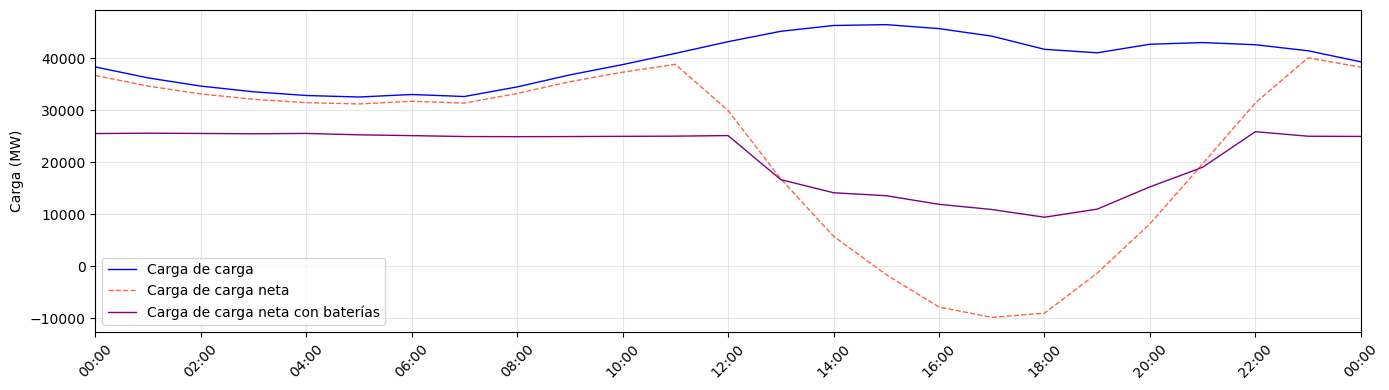


=== Net Load Statistics (after storage) for Total System ===
Average net load (no storage):   22708.43 MW
Average net load (with storage): 21026.18 MW
Peak net load (no storage):      40104.38 MW (at 2013-03-13 23:00:00)
Peak net load (with storage):    25883.71 MW (at 2013-03-13 22:00:00)
Min net load (no storage):       -9878.13 MW (at 2013-03-13 17:00:00)
Min net load (with storage):     9409.76 MW (at 2013-03-13 18:00:00)

Average discharge: 5765.46 MW
Average charge:    4083.21 MW
Peak discharge:    15099.28 MW
Peak charge:       20776.53 MW


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========================================
# USER INPUT: Change this to select a bus
# ========================================
selected_bus = ""  # Change this to any bus name, or "" to plot the total system
# ========================================

# --- LOAD ---
load_data = n.loads_t.p_set

if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    loads_in_bus = n.loads[n.loads.bus == selected_bus].index
    if len(loads_in_bus) == 0:
        print(f"ERROR: No loads found for bus '{selected_bus}'")
        print(f"\nAvailable buses:")
        print(n.buses.index.tolist())
        raise ValueError(f"Bus '{selected_bus}' not found or has no loads")
    bus_load_MW = load_data[loads_in_bus].sum(axis=1)
    title_suffix = f"Bus: {selected_bus}"
    print(f"Plotting net load curve (after storage) for bus: {selected_bus}")
else:
    bus_load_MW = load_data.sum(axis=1)
    title_suffix = "Total System"
    print("Plotting total system net load curve (after storage)")

# --- RENEWABLE GENERATION ---
renewable_carriers = ["solar", "onwind"]

gen_t = n.generators_t.p
renewable_gens = n.generators[n.generators.carrier.isin(renewable_carriers)].index
renewable_gens_active = [g for g in renewable_gens if g in gen_t.columns]

if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    renewable_gens_active = [
        g for g in renewable_gens_active
        if n.generators.loc[g, "bus"] == selected_bus
    ]

renewable_gen_MW = (
    gen_t[renewable_gens_active].sum(axis=1)
    if renewable_gens_active
    else pd.Series(0, index=bus_load_MW.index)
)

print(f"Renewable carriers found: {n.generators[n.generators.carrier.isin(renewable_carriers)].carrier.unique().tolist()}")
print(f"Number of active renewable generators: {len(renewable_gens_active)}")

# --- STORAGE (PHS and batteries only) ---
battery_carriers = ["battery", "PHS"]  # adjust if your carrier names differ

storage_t = n.storage_units_t.p
storage_units_active = [s for s in n.storage_units.index if s in storage_t.columns]
storage_units_active = [
    s for s in storage_units_active
    if n.storage_units.loc[s, "carrier"] in battery_carriers
]

if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    storage_units_active = [
        s for s in storage_units_active
        if n.storage_units.loc[s, "bus"] == selected_bus
    ]

storage_net_MW = (
    storage_t[storage_units_active].sum(axis=1)
    if storage_units_active
    else pd.Series(0, index=bus_load_MW.index)
)

discharge_MW = storage_net_MW.clip(lower=0)
charge_MW    = (-storage_net_MW).clip(lower=0)

print(f"Number of active storage units (PHS + battery): {len(storage_units_active)}")

# --- NET LOAD CURVES ---
net_load_MW         = bus_load_MW - renewable_gen_MW
net_load_storage_MW = net_load_MW - storage_net_MW

# --- TIME WINDOW ---
start = pd.Timestamp("2013-03-13 00:00:00")
end   = pd.Timestamp("2013-03-14 00:00:00")

def slice_ts(series):
    return series.loc[(series.index >= start) & (series.index <= end)]

selected_load          = slice_ts(bus_load_MW)
selected_renewable     = slice_ts(renewable_gen_MW)
selected_net_load      = slice_ts(net_load_MW)
selected_net_load_stor = slice_ts(net_load_storage_MW)
selected_discharge     = slice_ts(discharge_MW)
selected_charge        = slice_ts(charge_MW)

# --- PLOT ---
plt.figure(figsize=(14, 4))
plt.plot(selected_load.index,          selected_load.values,          linewidth=1, label="Carga de carga",             color="blue")
plt.plot(selected_net_load.index,      selected_net_load.values,      linewidth=1, label="Carga de carga neta", color="tomato", linestyle="--")
plt.plot(selected_net_load_stor.index, selected_net_load_stor.values, linewidth=1, label="Carga de carga neta con baterías", color="purple")

plt.ylabel("Carga (MW)")
plt.xlim(start, end)
plt.legend()

ax = plt.gca()
duration = (end - start).days

if duration <= 1:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
elif duration <= 7:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:00'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
elif duration <= 31:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
elif duration <= 90:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# --- SAVE ---
if selected_bus is not None and selected_bus != "" and selected_bus != "None":
    filename = f"net_load_storage_curve_{selected_bus}.png"
else:
    filename = "net_load_storage_curve_system.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Plot saved as: {filename}")
plt.show()

# --- STATS ---
print(f"\n=== Net Load Statistics (after storage) for {title_suffix} ===")
print(f"Average net load (no storage):   {selected_net_load.mean():.2f} MW")
print(f"Average net load (with storage): {selected_net_load_stor.mean():.2f} MW")
print(f"Peak net load (no storage):      {selected_net_load.max():.2f} MW (at {selected_net_load.idxmax()})")
print(f"Peak net load (with storage):    {selected_net_load_stor.max():.2f} MW (at {selected_net_load_stor.idxmax()})")
print(f"Min net load (no storage):       {selected_net_load.min():.2f} MW (at {selected_net_load.idxmin()})")
print(f"Min net load (with storage):     {selected_net_load_stor.min():.2f} MW (at {selected_net_load_stor.idxmin()})")
print(f"\nAverage discharge: {selected_discharge.mean():.2f} MW")
print(f"Average charge:    {selected_charge.mean():.2f} MW")
print(f"Peak discharge:    {selected_discharge.max():.2f} MW")
print(f"Peak charge:       {selected_charge.max():.2f} MW")